# Gemini API: Browser as a tool

LLMs are powerful tools, but are not intrinsically connected to live data sources. Features like Google Search grounding provide fresh information using Google's search index, but to supply truly live information, you can connect a browser to provide up-to-the-minute data and smart exploration.

This notebook will guide you through three examples of using a browser as a tool with the Gemini API, using both the [Live Multimodal API](https://ai.google.dev/api/multimodal-live) and traditional turn-based conversations.

- Requesting live data using a browser tool with the Live API
- Returning images of web pages from function calling
- Connecting to a local network/intranet using a browser tool


## Setup

### Install the Google GenAI SDK

Install the Google GenAI SDK from [npm](https://www.npmjs.com/package/@google/genai). 

```bash
$ npm install @google/genai
```

### Setup your API key

You can [create](https://aistudio.google.com/app/apikey) your API key using Google AI Studio with a single click.

Remember to treat your API key like a password. Don't accidentally save it in a notebook or source file you later commit to GitHub. In this notebook we will be storing the API key in a `.env` file. You can also set it as an environment variable or use a secret manager. 

Here's how to set it up in a `.env` file:

```bash
$ touch .env
$ echo "GEMINI_API_KEY=<YOUR_API_KEY>" >> .env
```

:::{.callout-tip}

Another option is to set the API key as an environment variable. You can do this in your terminal with the following command:

```bash
$ export GEMINI_API_KEY="<YOUR_API_KEY>"
```
:::

### Load the API key

To load the API key from the `.env` file, we will use the `dotenv` package. This package loads environment variables from a `.env` file into `process.env`. 

```bash
$ npm install dotenv
```

Then, we can load the API key in our code:


In [8]:
const dotenv = require("dotenv") as typeof import("dotenv");

dotenv.config({
  path: "../.env",
});

const GEMINI_API_KEY = process.env.GEMINI_API_KEY ?? "";
if (!GEMINI_API_KEY) {
  throw new Error("GEMINI_API_KEY is not set in the environment variables");
}
console.log("GEMINI_API_KEY is set in the environment variables");


GEMINI_API_KEY is set in the environment variables


:::{.callout-note}
In our particular case the `.env` is is one directory up from the notebook, hence we need to use `../` to go up one directory. If the `.env` file is in the same directory as the notebook, you can omit it altogether. 

```
│
├── .env
└── examples
    └── Browser_as_tool.ipynb
```
:::


### Initialize SDK Client

With the new SDK, now you only need to initialize a client with you API key (or OAuth if using [Vertex AI](https://cloud.google.com/vertex-ai)). The model is now set in each call.


In [9]:
const google = require("@google/genai") as typeof import("@google/genai");

const ai = new google.GoogleGenAI({ apiKey: GEMINI_API_KEY });


### Select a model

Now select the model you want to use in this guide, either by selecting one in the list or writing it down. Keep in mind that some models, like the 2.5 ones are thinking models and thus take slightly more time to respond (cf. [thinking notebook](../quickstarts/Get_started_thinking.ipynb) for more details and in particular learn how to switch the thiking off).


In [10]:
const tslab = require("tslab") as typeof import("tslab");

const MODEL_ID = "gemini-2.5-flash-preview-05-20";
const LIVE_MODEL_ID = "gemini-2.0-flash-live-001";


## Utilities

The `showParts` helper renders the deeply nested output that the API returns in an notebook-friendly way; handling text, code and tool calls.

The `canCrawlUrl` helper will perform a robots.txt check to ensure any automated requests are welcome by the remote service.


In [ ]:
import {
  FunctionResponse,
  GenerateContentResponse,
  LiveServerContent,
  LiveServerToolCall,
  Session,
} from "@google/genai";
import robotsParser from "robots-parser";

// eslint-disable-next-line complexity
function showParts(content: GenerateContentResponse) {
  const parts = content.candidates?.[0]?.content?.parts ?? [];
  if (parts.length === 0) {
    tslab.display.markdown("\n-------------------------------\n");
    tslab.display.markdown(`**Finish Reason:** ${content.candidates?.[0]?.finishReason ?? "unknown"}`);
    return;
  }
  for (const part of parts) {
    if (part.text) {
      tslab.display.markdown(part.text);
    } else if (part.executableCode) {
      tslab.display.markdown("\n-------------------------------\n");
      tslab.display.markdown(`\`\`\`python\n${part.executableCode.code}\n\`\`\``);
      tslab.display.markdown("\n-------------------------------\n");
    } else if (part.codeExecutionResult) {
      tslab.display.markdown("\n-------------------------------\n");
      tslab.display.markdown(`\`\`\`\n${part.codeExecutionResult.output}\n\`\`\``);
      tslab.display.markdown("\n-------------------------------\n");
    } else {
      console.log(JSON.stringify(part, null, 2));
    }
  }
  const groundingMetadata = content.candidates?.[0]?.groundingMetadata;
  if (groundingMetadata) {
    tslab.display.html(groundingMetadata.searchEntryPoint?.renderedContent ?? "");
  }
}

function handleServerContent(content: LiveServerContent) {
  if (content.modelTurn) {
    for (const turn of content.modelTurn.parts ?? []) {
      if (turn.executableCode) {
        tslab.display.markdown(`\`\`\`python\n${turn.executableCode.code}\n\`\`\``);
      }
      if (turn.codeExecutionResult) {
        tslab.display.markdown(`\`\`\`\n${turn.codeExecutionResult.output}\n\`\`\``);
      }
    }
  }
  if (content.groundingMetadata) {
    tslab.display.html(content.groundingMetadata.searchEntryPoint?.renderedContent ?? "");
  }
}
function handleToolCall(session: Session, toolCall: LiveServerToolCall) {
  console.log("Tool call received:", JSON.stringify(toolCall, null, 2));
  const responses: FunctionResponse[] = [];
  for (const fc of toolCall.functionCalls ?? []) {
    responses.push({
      id: fc.id,
      name: fc.name,
      response: {
        result: "ok",
      },
    });
  }
  console.log("Tool call responses:", JSON.stringify(responses, null, 2));
  session.sendToolResponse({
    functionResponses: responses,
  });
}

async function canCrawlUrl(url: string, userAgent = "*"): Promise<boolean> {
  try {
    const parsedUrl = new URL(url);
    const robotsUrl = `${parsedUrl.protocol}//${parsedUrl.host}/robots.txt`;
    const response = await fetch(robotsUrl);
    if (!response.ok) {
      console.error(`Failed to fetch robots.txt from ${robotsUrl}: ${response.statusText}`);
      return false; // If we can't fetch the robots.txt, assume we can't crawl.
    }
    const robotsTxt = await response.text();
    // eslint-disable-next-line @typescript-eslint/no-unsafe-call, @typescript-eslint/no-unsafe-member-access
    return robotsParser(robotsUrl, robotsTxt).isAllowed(robotsUrl, userAgent) as boolean;
  } catch (e) {
    console.error(`Error checking robots.txt: ${e}`);
    return false; // Be a good citizen: fail closed.
  }
}


## Browsing live

This example will show you how to use the Multimodal Live API with the Google Search tool, and then comparatively shows a custom web browsing tool to retrieve site contents in real-time.


### Use Google Search as a tool

The streaming nature of the Live API requires that the stream processing and function handling code be written in advance. This allows the stream to continue without timing out.

This example uses text as the input mode, and streams text back out, but the technique applies any mode supported by the Live API, including audio.


In [5]:
import { Modality, Tool } from "@google/genai";

async function run(prompt: string, modality: Modality = Modality.TEXT, tools: Tool[] = [], systemInstructions = "") {
  let completed = false;
  let textAccumulator = "";
  let flushText = false;
  const session = await ai.live.connect({
    model: LIVE_MODEL_ID,
    callbacks: {
      onopen: () => {
        console.log("Connection opened");
      },
      onclose: () => {
        console.log("Connection closed");
      },
      onerror: (error) => {
        console.error("Error:", error.message);
      },
      onmessage: (message) => {
        if (message.text) {
          textAccumulator += message.text;
          return;
        }
        flushText = message.serverContent !== undefined || message.toolCall !== undefined;
        if (flushText && textAccumulator) {
          tslab.display.markdown(textAccumulator);
          textAccumulator = "";
          flushText = false;
        }
        if (message.serverContent) {
          handleServerContent(message.serverContent);
          if (message.serverContent.turnComplete) {
            completed = true;
          }
          return;
        }
        if (message.toolCall) {
          handleToolCall(session, message.toolCall);
          completed = true;
          return;
        }
      },
    },
    config: {
      tools: tools,
      responseModalities: [modality],
      systemInstruction: systemInstructions,
    },
  });
  session.sendClientContent({
    turns: [prompt],
    turnComplete: true,
  });
  // eslint-disable-next-line @typescript-eslint/no-unnecessary-condition
  while (!completed) {
    await new Promise((resolve) => setTimeout(resolve, 100));
  }
  session.close();
}


Now define and run the conversation.


In [11]:
// temporarily make console.warn a no-op to avoid warnings in the output (non-text part in GenerateContentResponse caused by accessing .text)
// https://github.com/googleapis/js-genai/blob/d82aba244bdb804b063ef8a983b2916c00b901d2/src/types.ts#L2005
// copy the original console.warn function to restore it later
const warn_fn = console.warn;
// eslint-disable-next-line @typescript-eslint/no-empty-function, no-empty-function
console.warn = function () {};

await run("What is today's featured article on the English Wikipedia?", google.Modality.TEXT, [{ googleSearch: {} }]);

// restore console.warn later
// console.warn = warn_fn;


Connection opened


```python
print(google_search.search(queries=["what is today's featured article on english wikipedia"]))

```

```
Looking up information on Google Search.

```

Today's featured article on the English Wikipedia is "Tritter".


what is today's featured article on english wikipedia

Connection closed


Depending on when you run this, you may note a discrepency between what Google Search has in its index, and what is currently live on Wikipedia. Check out [Wikipedia's featured article](https://en.wikipedia.org/wiki/Main_Page#mp-tfa) yourself. Alternatively, the model may decide not to answer due to the requirement for freshness.

To improve this situation, add a browse tool so the model can acquire this information in real-time.


### Add a live browser

This step defines a "browser" that requests a URL over HTTP(S), converts the response to markdown and returns it.

This technique works for sites that serve content as full HTML, so sites that rely on scripting to serve content, such as a [PWA](https://developer.mozilla.org/en-US/docs/Web/Progressive_web_apps) without [SSR](https://developer.mozilla.org/en-US/docs/Glossary/SSR), will not work. Check out the visual example later that uses a fully-featured browser.


In [ ]:
const TurndownService = require("turndown") as typeof import("turndown");

async function loadPage(url: string): Promise<string> {
  if (!(await canCrawlUrl(url))) {
    console.error(`Cannot crawl ${url} due to robots.txt restrictions.`);
    return "";
  }
  const page = await fetch(url);
  if (!page.ok) {
    console.error(`Failed to fetch ${url}: ${page.statusText}`);
    return "";
  }
  const html = await page.text();
  const turndownService = new TurndownService();
  const markdown = turndownService.turndown(html);
  return markdown;
}


In [17]:
import { FunctionDeclaration } from "@google/genai";

const loadPagePageDef: FunctionDeclaration = {
  name: "loadPage",
  description: "Load a web page and return its content in Markdown format.",
  parameters: {
    type: google.Type.OBJECT,
    properties: {
      url: {
        type: google.Type.STRING,
        description: "The URL of the web page to load.",
      },
    },
    required: ["url"],
  },
  response: {
    type: google.Type.OBJECT,
    properties: {
      result: {
        type: google.Type.STRING,
        description: "The requested webpage content in markdown format.",
      },
    },
    required: ["result"],
  },
};


In [12]:
await run(
  "What is today's featured article on the English Wikipedia?",
  google.Modality.TEXT,
  [{ functionDeclarations: [loadPagePageDef] }],
  `
  Your job is to answer the users query using the tools available.

  First determine the address that will have the information and tell the user. Then immediately
  invoke the tool. Then answer the user.
  `
);


Connection opened


I can load the main page of the English Wikipedia and find the featured article. The URL for that page is "https://en.wikipedia.org/wiki/Main_Page".


```python
print(default_api.loadPage(url="https://en.wikipedia.org/wiki/Main_Page"))

```

Tool call received: {
  "functionCalls": [
    {
      "id": "function-call-4631648064980030826",
      "args": {
        "url": "https://en.wikipedia.org/wiki/Main_Page"
      },
      "name": "loadPage"
    }
  ]
}
Tool call responses: [
  {
    "id": "function-call-4631648064980030826",
    "name": "loadPage",
    "response": {
      "result": "ok"
    }
  }
]


```
DefaultApi.LoadpageResponse(result='ok')

```

Connection closed


## Browse pages visually

In the previous example, you used a tool to retrieve a page's textual content and use it in a live chat context. However, web pages are a rich multi-modal medium, so using text results in some loss of signal. Using a fully-featured web browser also enables websites that use JavaScript to render content, something that is not possible using a simple HTTP request like the earlier example.

In this example, you will define a tool that takes a screenshot of a web page and passes the image back to the model.


### Define a graphical browser

Here you define a `browseUrl` function that uses [Puppeteer](https://pptr.dev/) to load a headless web browser, navigate to a URL and take a screenshot. This technique takes a single screenshot at a fixed size. 


In [ ]:
const fs = require("fs") as typeof import("fs");
const path = require("path") as typeof import("path");
const puppeteer = require("puppeteer") as typeof import("puppeteer");

const SCREENSHOT_FILE = path.join("../assets/browser_as_a_tool", "screenshot.png");

async function browseUrl(url: string): Promise<string> {
  if (!(await canCrawlUrl(url))) {
    return `URL ${url} failed a robots.txt check.`;
  }

  let browser: Awaited<ReturnType<typeof puppeteer.launch>> | undefined;
  try {
    browser = await puppeteer.launch({
      headless: true,
      args: ["--no-sandbox", "--disable-setuid-sandbox"],
    });

    const page = await browser.newPage();
    await page.setViewport({ width: 1024, height: 2048 });
    await page.goto(url, { waitUntil: "networkidle2", timeout: 30000 });

    // Wait for dynamic content
    await new Promise((resolve) => setTimeout(resolve, 5000));

    const base64Image = await page.screenshot();
    fs.writeFileSync(SCREENSHOT_FILE, base64Image);

    console.log(`Screenshot saved to ${SCREENSHOT_FILE}`);
    return "ok";
  } catch (err) {
    console.error("An error occurred:", err);
    return String(err);
  } finally {
    if (browser) await browser.close();
  }
}


In [6]:
await browseUrl("https://en.wikipedia.org/wiki/Castle");


Screenshot saved to ../assets/browser_as_a_tool/screenshot.png
ok


Check out the screenshot to make sure it worked.


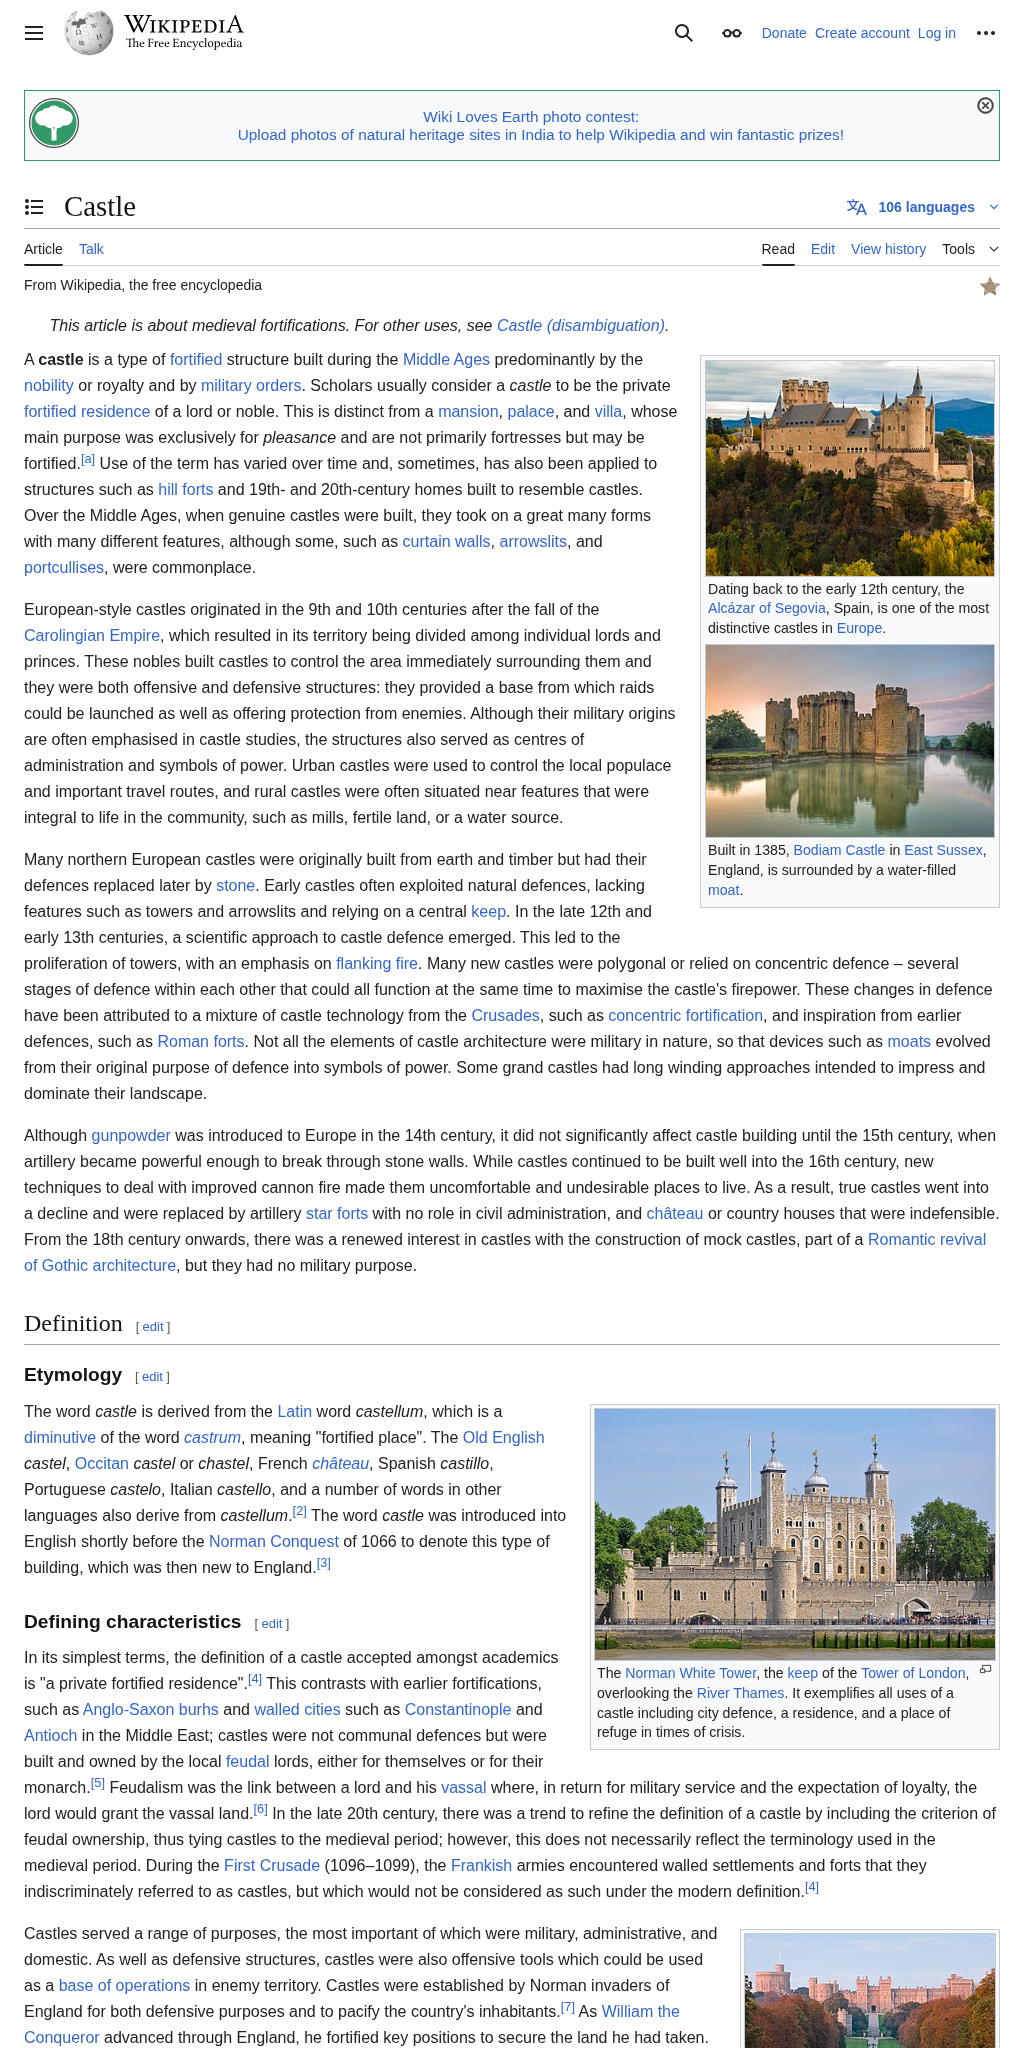

In [18]:
tslab.display.png(fs.readFileSync(SCREENSHOT_FILE));


### Connect the browser to the model

Add the `browseUrl` tool to a model and start a chat session. As LLMs do not directly have internet connectivity, modern models like Gemini are trained to tell users that they can't access the internet, rather than hallucinating results. To override this behaviour, this step adds a system instruction that guides the model to use the tool for internet access.


In [9]:
import { FunctionDeclaration } from "@google/genai";

const browseUrlPageDef: FunctionDeclaration = {
  name: "browseUrl",
  description: "Browse a web page and take a screenshot.",
  parameters: {
    type: google.Type.OBJECT,
    properties: {
      url: {
        type: google.Type.STRING,
        description: "The URL of the web page to browse.",
      },
    },
    required: ["url"],
  },
  response: {
    type: google.Type.OBJECT,
    properties: {
      result: {
        type: google.Type.STRING,
        description: "The status of the operation, e.g., 'ok' or an error message.",
      },
    },
    required: ["result"],
  },
};


In [10]:
const SYSTEM_INSTRUCTION = `
You are a system with access to websites via the \`browseUrl\` tool.
Use the \`browseUrl\` tool to browse a URL and generate a screenshot that will be
returned for you to see and inspect, like using a web browser.

When a user requests information, first use your knowledge to determine a specific
page URL, tell the user the URL and then invoke the \`browseUrlPageDef\` with this URL. The
tool will supply the website, at which point you will examine the contents of the
screenshot to answer the user's questions. Do not ask the user to proceed, just act.

You will not be able to inspect the page HTML, so determine the most specific page
URL, rather than starting navigation from a site's homepage.
`;
const chat = ai.chats.create({
  model: MODEL_ID,
  config: {
    tools: [{ functionDeclarations: [browseUrlPageDef] }],
    systemInstruction: SYSTEM_INSTRUCTION,
  },
});
const r = await chat.sendMessage({
  message: "What is trending on YouTube right now?",
});
showParts(r);


I will browse the YouTube trending page at https://www.youtube.com/feed/trending.

{
  "functionCall": {
    "name": "browseUrl",
    "args": {
      "url": "https://www.youtube.com/feed/trending"
    }
  }
}


You should see a `functionCall` in the response above. Once the model issues a function call, execute the tool and save both the `functionResponse` and the image for the next turn.

If you do not see a `functionCall`, you can either re-run the cell, or continue the chat to answer any questions the model has (e.g. `r = await chat.sendMessage({ message: "Yes, please use the tool" })`);


In [11]:
import { Part } from "@google/genai";

let functionResponse: Part;
const parts = r.candidates?.[0]?.content?.parts ?? [];
for (const part of parts) {
  if (part.functionCall) {
    console.assert(part.functionCall.name === "browseUrl", "Expected function call to be browseUrl");
    const url = part.functionCall.args?.url as string;
    console.log(`Browsing URL: ${url}`);
    const response = await browseUrl(url);
    console.log(`Response: ${response}`);
    if (response !== "ok") {
      console.error(`Failed to browse URL ${url}: ${response}`);
    }
    functionResponse = google.createPartFromFunctionResponse(part.functionCall.id, part.functionCall.name, {
      result: response,
    });
  }
}


Browsing URL: https://www.youtube.com/feed/trending
Screenshot saved to ../assets/browser_as_a_tool/screenshot.png
Response: ok


Inspect the image before it is sent back to the model. Depending on where you are running this, you may see localised content. If you are using Google Colab, you can run `!curl ipinfo.io` to see the geolocation of the running kernal.

Note that if you see a semi-blank image, the page may not have fully loaded. Try adjusting the sleep duration in `browseUrl`, or provide a suitable implementation for the pages you are using in your application.


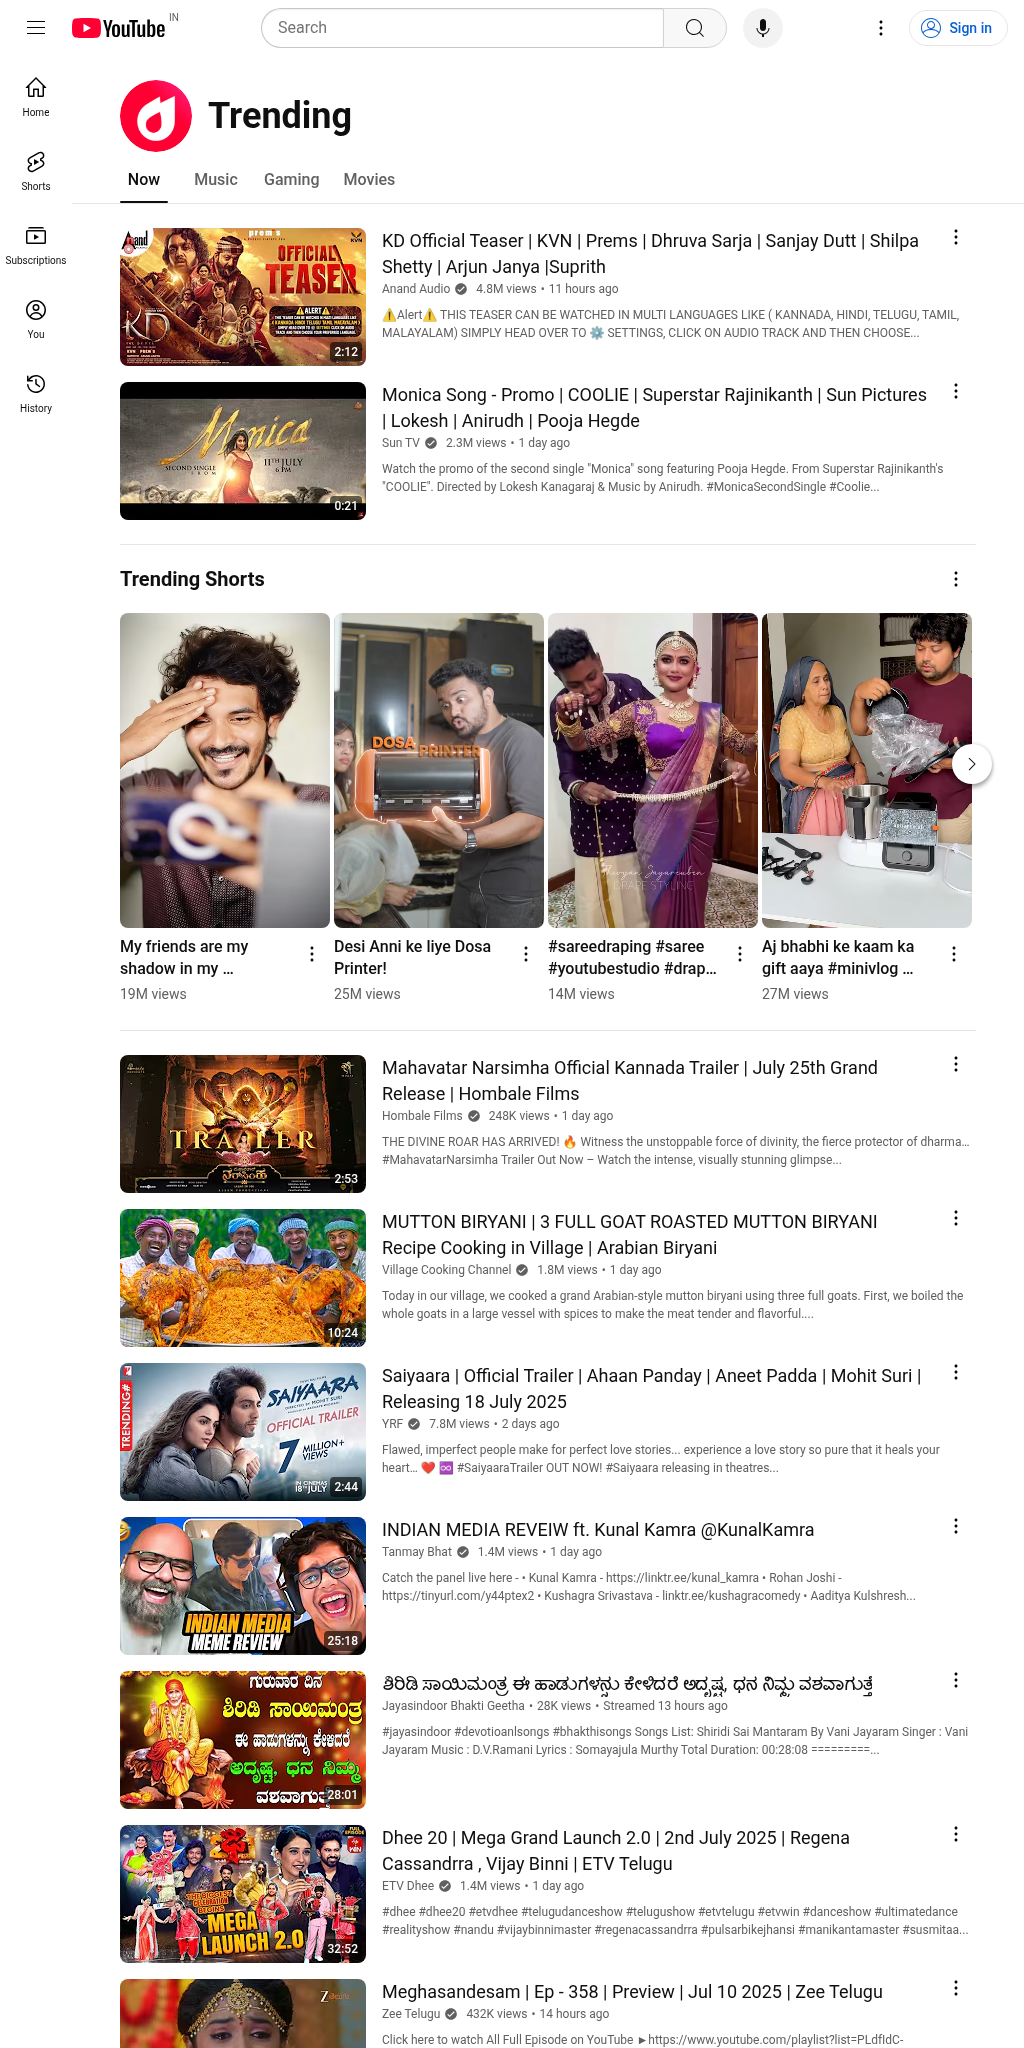

In [12]:
tslab.display.png(fs.readFileSync(SCREENSHOT_FILE));


In [40]:
const r2 = await chat.sendMessage({
  message: [
    functionResponse,
    google.createPartFromBase64(fs.readFileSync(SCREENSHOT_FILE).toString("base64"), "image/png"),
  ],
});
showParts(r2);


Based on the trending page on YouTube, here's what is currently trending:

**Top Trending Videos:**

*   **KD Official Teaser | KVN | Prems | Dhruva Sarja | Sanjay Dutt | Shilpa Shetty | Arjun Janya |Suprith** by Anand Audio (4.5M views, 11 hours ago)
*   **Monica Song - Promo | COOLIE | Superstar Rajinikanth | Sun Pictures | Lokesh | Anirudh | Pooja Hegde** by Sun TV (2.3M views, 1 day ago)
*   **Mahavatar Narsimha Official Kannada Trailer | July 25th Grand Release | Hombale Films** by Hombale Films (245K views, 1 day ago)
*   **MUTTON BIRYANI | 3 FULL GOAT ROASTED MUTTON BIRYANI Recipe Cooking in Village | Arabian Biryani** by Village Cooking Channel (1.7M views, 1 day ago)
*   **Saiyaara | Official Trailer | Ahaan Panday | Aneet Paddda | Mohit Suri | Releasing 18 July 2025** by YRF (7.7M views, 2 days ago)
*   **INDIAN MEDIA REVEIW ft. Kunal Kamra @KunalKamra** by Tanmay Bhat (1.4M views, 1 day ago)
*   A devotional song in Telugu by Jayasindoor Bhakti Geetha (28K views, 13 hours ago)
*   **Dhee 20 | Mega Grand Launch 2.0 | 2nd July 2025 | Regena Cassandra , Vijay Binni | ETV Telugu** by ETV Dhee (1.4M views, 1 day ago)
*   **Meghasandesam | Ep - 358 | Preview | Jul 10 2025 | Zee Telugu** by Zee Telugu (421K views, 14 hours ago)

**Trending Shorts:**

*   "My friends are my shadow in my ..." (19M views)
*   "Desi Anni ke liye Dosa Printer!" (24M views)
*   A short related to #sareedraping (14M views)
*   "Aj bhabhi ke kaam ka gift aaya #minivlog ..." (27M views)

## Browse local services

By providing a browse tool that you run in your own environment, you can connect it to your own private services - such as your home network or intranet.

This example demonstrates how to connect the browse tool to a simulated intranet environment.

First download the sample intranet files.


In [19]:
const AdmZip = require("adm-zip") as typeof import("adm-zip");

const DATA_URL = "https://storage.googleapis.com/generativeai-downloads/data/intranet.zip";
const EXTRACT_PATH = "../assets/browser_as_a_tool";

async function downloadAndExtractDataset(): Promise<void> {
  if (fs.existsSync(`${EXTRACT_PATH}/intranet`)) {
    console.log("Dataset already exists. Skipping download.");
    return;
  }

  const response = await fetch(DATA_URL);
  const buffer = await response.arrayBuffer();

  console.log("Extracting dataset...");
  await fs.promises.mkdir(EXTRACT_PATH, { recursive: true });

  const zipPath = path.join(EXTRACT_PATH, "intranet.zip");
  fs.writeFileSync(zipPath, Buffer.from(buffer));

  const zip = new AdmZip(zipPath);
  zip.extractAllTo(EXTRACT_PATH, true);

  console.log("Dataset extracted.");
}

await downloadAndExtractDataset();


Dataset already exists. Skipping download.


Set up a HTTP server that serves those files in a background thread, so that you can access it using the main foreground thread.


In [ ]:
import mime from "mime";
import http from "http";

const PORT = 8080;
const DIRECTORY = path.join("../assets/browser_as_a_tool", "intranet");

const server = http.createServer((req, res) => {
  let filePath = path.join(DIRECTORY, decodeURIComponent(req.url));
  if (fs.statSync(DIRECTORY).isDirectory() && req.url === "/") {
    filePath = path.join(DIRECTORY, "index.html");
  }

  fs.readFile(filePath, (err, content) => {
    if (err) {
      res.writeHead(404, { "Content-Type": "text/plain" });
      res.end("404 - File Not Found");
      return;
    }
    const contentType = mime.getType(filePath) ?? "application/octet-stream";
    res.writeHead(200, { "Content-Type": contentType });
    res.end(content);
  });
});

server.listen(PORT, () => {
  console.log(`Server started on http://localhost:${PORT}`);
});


<ref *1> Server {
  maxHeaderSize: undefined,
  insecureHTTPParser: undefined,
  requestTimeout: 300000,
  headersTimeout: 60000,
  keepAliveTimeout: 5000,
  connectionsCheckingInterval: 30000,
  requireHostHeader: true,
  joinDuplicateHeaders: undefined,
  rejectNonStandardBodyWrites: false,
  _events: [Object: null prototype] {
    request: [Function (anonymous)],
    connection: [Function: connectionListener],
    listening: [ [Function: setupConnectionsTracking], [Function] ]
  },
  _eventsCount: 3,
  _maxListeners: undefined,
  _connections: 0,
  _handle: TCP {
    reading: false,
    onconnection: [Function: onconnection],
    [Symbol(owner_symbol)]: [Circular *1]
  },
  _usingWorkers: false,
  _workers: [],
  _unref: false,
  _listeningId: 2,
  allowHalfOpen: true,
  pauseOnConnect: false,
  noDelay: true,
  keepAlive: false,
  keepAliveInitialDelay: 0,
  highWaterMark: 16384,
  httpAllowHalfOpen: false,
  timeout: 0,
  maxHeadersCount: null,
  maxRequestsPerSocket: 0,
  _connec

Take a screenshot to see what the intranet home page looks like.


Screenshot saved to ../assets/browser_as_a_tool/screenshot.png


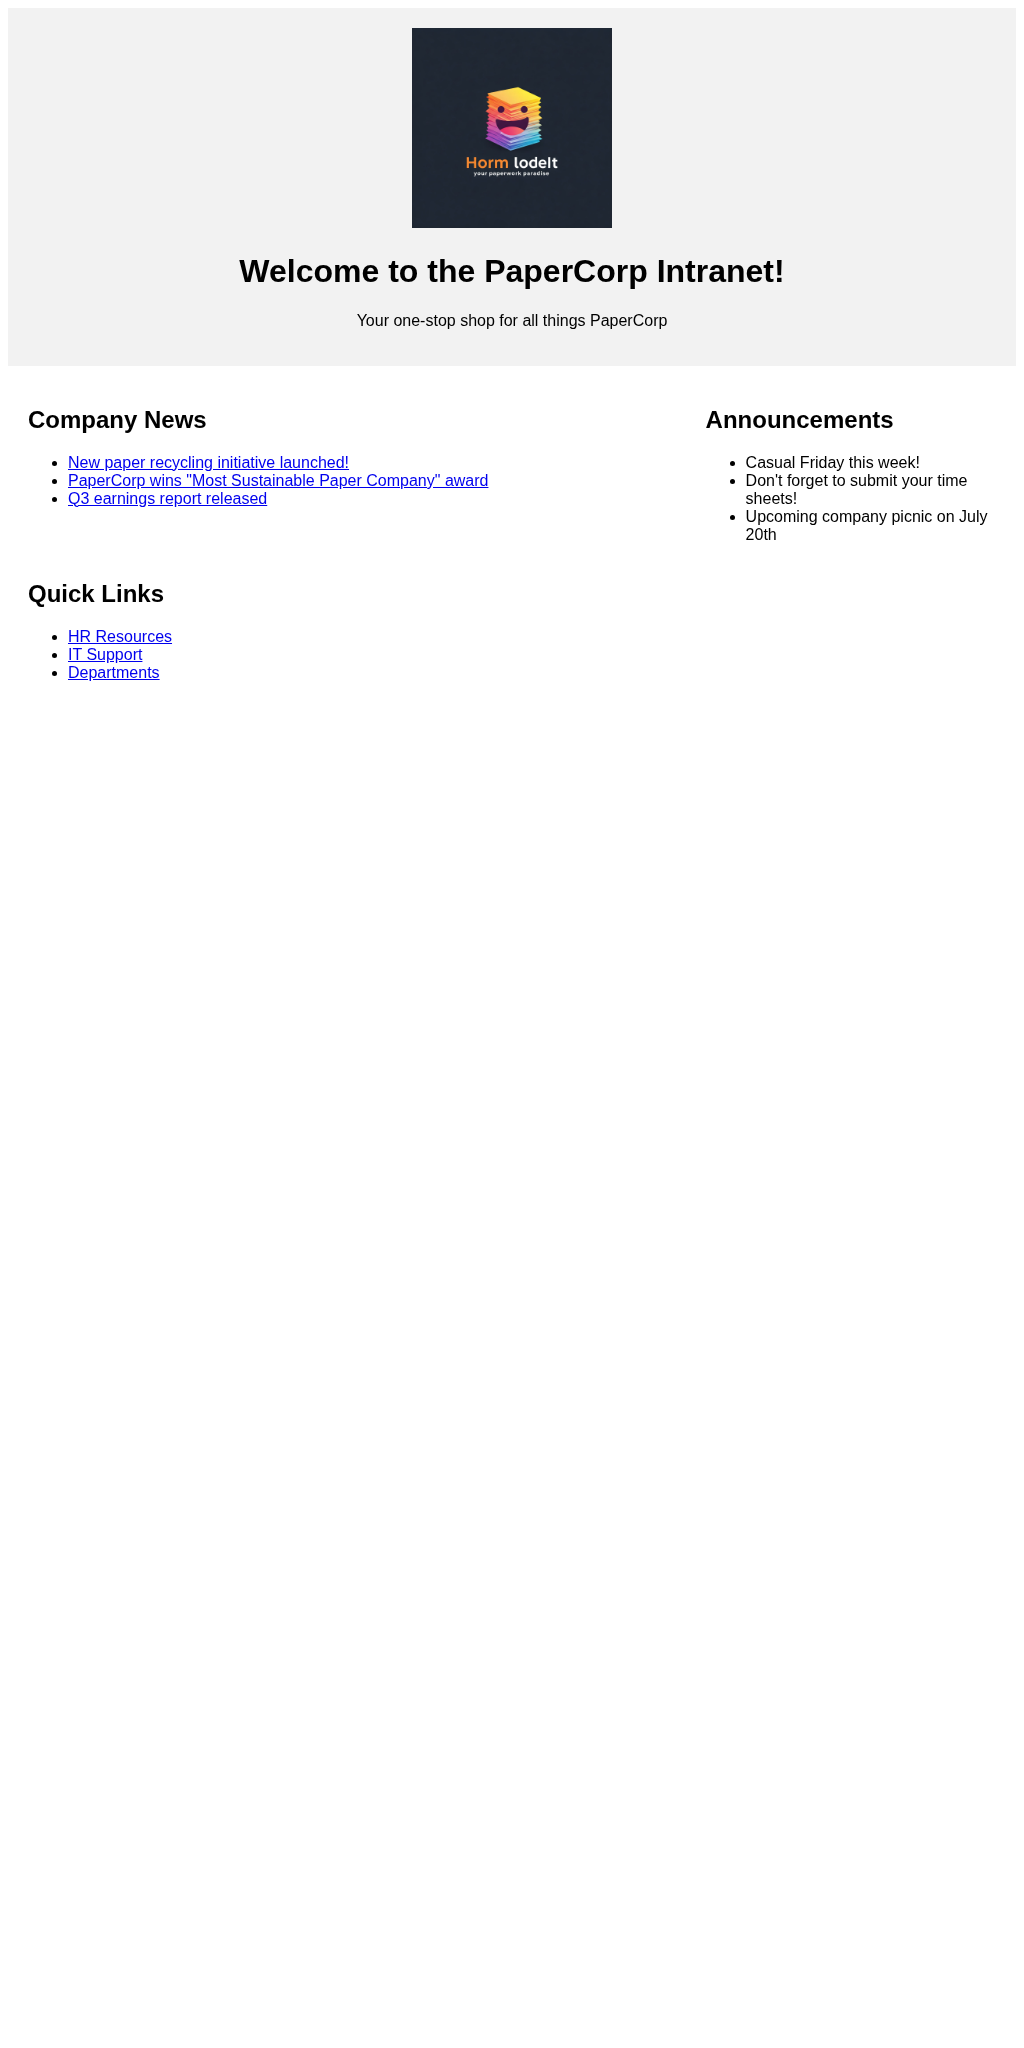

In [13]:
await browseUrl("http://localhost:8080");
tslab.display.png(fs.readFileSync(SCREENSHOT_FILE));


Finally, start a chat that uses the `loadPage` tool. Include instructions on how to access and navigate the intranet.

:::{.callout-note}

If the data you provide to the model is at all sensitive, be sure to read and understand the [terms and conditions](https://ai.google.dev/gemini-api/terms#data-use-unpaid) for the Gemini API, specifically the terms governing how data is processed for paid vs unpaid services.

:::


In [ ]:
import { CallableTool, FunctionCall, Tool } from "@google/genai";

const loadPageTool: CallableTool = {
  callTool: async (calls: FunctionCall[]) => {
    const call = calls[0];
    const { url } = call.args as { url: string };
    const markdown = await loadPage(url);
    return [
      google.createPartFromFunctionResponse(call.id ?? "", call.name ?? "", {
        result: markdown,
      }),
    ];
  },
  tool: async (): Promise<Tool> => await Promise.resolve({ functionDeclarations: [loadPagePageDef] }),
};


In [23]:
const PAPER_CORP_SYSTEM_INSTRUCTION = `
  Use the tools you have to answer the user's questions about
  the "PaperCorp" company.
  
  You have access to web pages through the \`loadPage\` tool, including access to the local
  network and intranet, where you will find information about the company. The \`loadPage\`
  tool will return you the page contents as Markdown.
  
  The intranet hostname is \`papercorp\`, and the home page can be accessed via
  http://localhost:8080.
  
  Unless you know an address already, start navigating from the home page to find other
  pages.
`;

const paper_corp_chat = ai.chats.create({
  model: MODEL_ID,
  config: {
    tools: [loadPageTool],
    systemInstruction: PAPER_CORP_SYSTEM_INSTRUCTION,
  },
});
const stream = await paper_corp_chat.sendMessageStream({
  message: "What forms are available through HR?",
});
for await (const chunk of stream) {
  showParts(chunk);
}


{
  "thoughtSignature": "CiwBVKhc7k+mAhFaUMhzli8xM7D6GNQx4ApsJvXq6Yj5oZIT94XhCeXnxgNXIwqEAQFUqFzucj+yJ8JZ7jAwZeEzyfkYn0+Fr7sWegQovyExMYKa7Otj15iy0AItBb8AmDlTYlWUhd4fXQpLsoOw+nHbtPd2Rj9UcnqVThXN6Y5Vme4gr2H97Sgl4SrGOdz+dbSjs/ok/WRNXCWrVtxyokeb09m9mUB6C+M/3HNvF+B8BMVfCgqfAQFUqFzu7sgaDSv+GMBwnyQdU0Zj8ovM1neJoJ0lpJsXaP2U6LMkdaPUun6XrqDPCjKCpGbg7t92ZPTTTpfF4EbQ7jcNdkJu1GTyVD0/bylfNEfCCBObpdh3f5/tLEK1PJ8GLpdvc+NwrEaTPM3Yl8mfzrmf6dIi9O7+H3Kdwl3ptVSS14npcbLHRsz2Hwrhm0/dAtXZpmyGrRiQ3PCEjA==",
  "functionCall": {
    "name": "loadPage",
    "args": {
      "url": "http://localhost:8080"
    }
  }
}
{
  "functionResponse": {
    "id": "",
    "name": "loadPage",
    "response": {
      "result": "Welcome to PaperCorp Intranet body { font-family: sans-serif; } .header { background-color: #f2f2f2; padding: 20px; text-align: center; } .logo { max-width: 200px; } .content { padding: 20px; } .news { float: left; width: 60%; } .announcements { float: right; width: 30%; } .clearfix::after { content: \"\"

The forms available through HR are:

*   Expense Report Form
*   Time Off Request Form
*   Benefits Enrollment Form
*   Tax Forms (W-2, etc.)


-------------------------------


**Finish Reason:** STOP

In [24]:
server.close(() => {
  console.log("Server closed");
});


Server {
  maxHeaderSize: undefined,
  insecureHTTPParser: undefined,
  requestTimeout: 300000,
  headersTimeout: 60000,
  keepAliveTimeout: 5000,
  connectionsCheckingInterval: 30000,
  requireHostHeader: true,
  joinDuplicateHeaders: undefined,
  rejectNonStandardBodyWrites: false,
  _events: [Object: null prototype] {
    request: [Function (anonymous)],
    connection: [Function: connectionListener],
    listening: [Function: setupConnectionsTracking],
    close: [Function: bound onceWrapper] { listener: [Function (anonymous)] }
  },
  _eventsCount: 4,
  _maxListeners: undefined,
  _connections: 0,
  _handle: null,
  _usingWorkers: false,
  _workers: [],
  _unref: false,
  _listeningId: 3,
  allowHalfOpen: true,
  pauseOnConnect: false,
  noDelay: true,
  keepAlive: false,
  keepAliveInitialDelay: 0,
  highWaterMark: 16384,
  httpAllowHalfOpen: false,
  timeout: 0,
  maxHeadersCount: null,
  maxRequestsPerSocket: 0,
  _connectionKey: '6::::8080',
  [Symbol(IncomingMessage)]: [Funct

## Further reading

- To learn more about using the search tools, try the [Search grounding](../quickstarts/Search_Grounding.ipynb) cookbook recipe.
- For more advanced examples of function calling in the Live API, try the [Plotting and Mapping](LiveAPI_plotting_and_mapping.ipynb) cookbook recipe.

Or browse the Gemini API cookbook.
